In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import matplotlib as mpl

# Global settings for publication-quality plots
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,          # Base font size
    "axes.titlesize": 10,    # Title font size
    "axes.labelsize": 9,     # X/Y label font size
    "xtick.labelsize": 8,    # Tick label font size
    "ytick.labelsize": 8,
    "legend.fontsize": 8,    # Legend font size

    # Line styles
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.figsize": (3.3, 2.5),  # ~1-column figure in most journals
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


In [3]:
trajx = []
trajy = []
for d in os.listdir('.'):
    if d.endswith('.dat'):
        data = np.loadtxt(d)
        trajx.append(data[:,1])
        trajy.append(data[:,2])

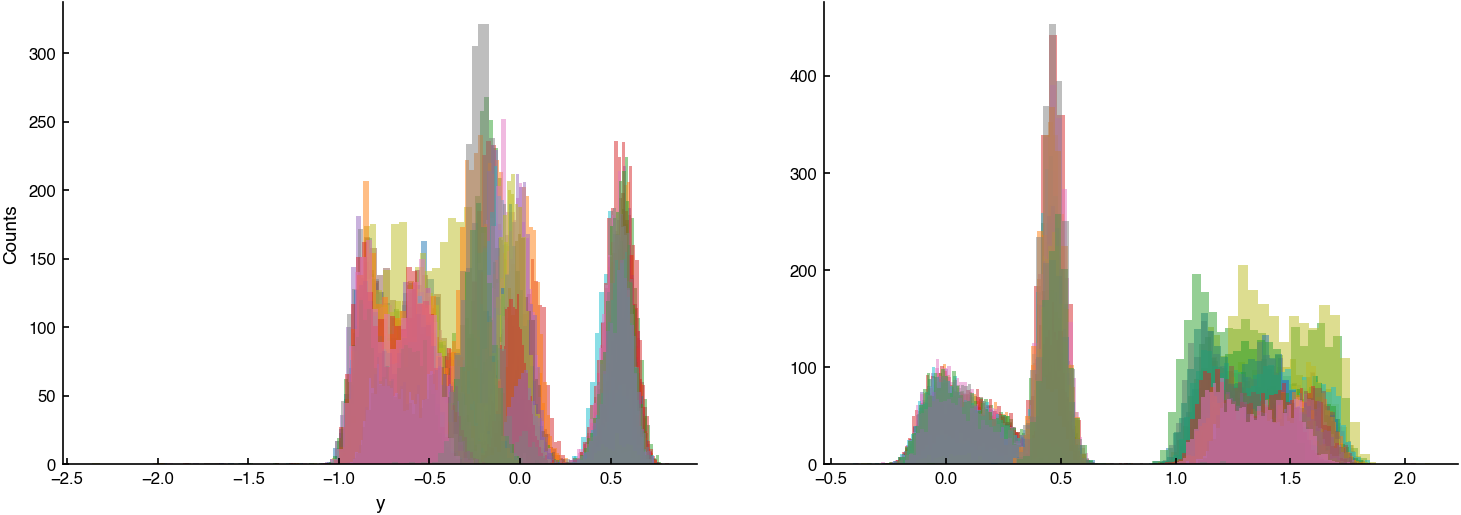

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
for traj1, traj2 in zip(trajx, trajy):
    ax[0].hist(traj1, bins=50, alpha=0.5)
    ax[1].hist(traj2, bins=50, alpha=0.5)
    ax[0].set_xlabel("x")
    ax[0].set_xlabel("y")
    ax[0].set_ylabel("Counts")
plt.show()

In [5]:
free = np.loadtxt('output.free')

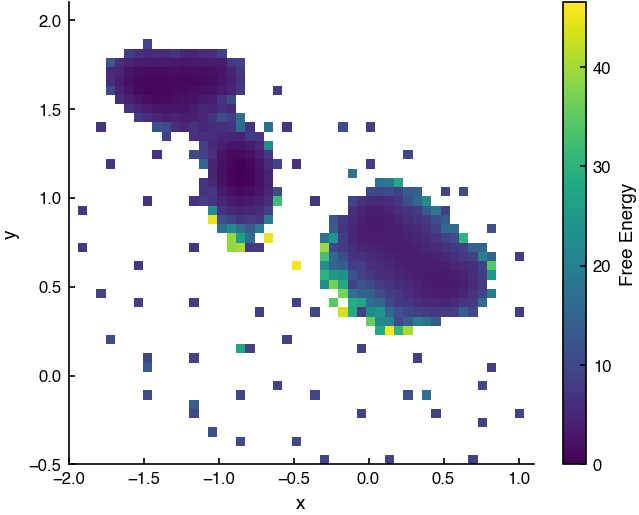

In [13]:
X, Y = np.meshgrid(np.unique(free[:,0]), np.unique(free[:,1]))
Z = free[:,2].reshape(X.shape)
Z = np.where(Z > 100, np.inf, Z)

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)
c = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
fig.colorbar(c, ax=ax, label='Free Energy')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

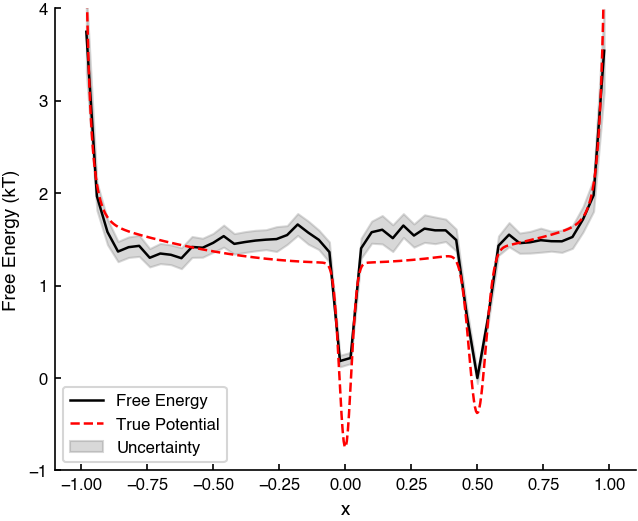

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)
ax.plot(free[:,0], free[:,1], label='Free Energy', color='black')
x_vals = np.linspace(-1.0, 1.0, 500)
f_true = potential(x_vals)
ax.plot(x_vals, f_true-f_true.mean()+free[:, 1].mean(), label='True Potential', color='red', linestyle='dashed')
ax.fill_between(free[:,0], free[:,1]-free[:,2], free[:,1]+free[:,2], alpha=0.3, color='gray', label='Uncertainty')
ax.set_ylim(-1, 4)
ax.set_xlabel("x")
ax.set_ylabel("Free Energy (kT)")
ax.legend()
plt.show()

In [28]:
f_true.min()

-1.9919820027923896